In [1]:
!pip install qiskit




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install qiskit-aer

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.6 MB 16.5 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 13.7 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 15.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 14.5 MB/s  0:00:00



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PART 1: TELEPORTATION -> PART A

In [20]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

import numpy as np

In [3]:
theta = 1.1
phi = 1.7

In [4]:
qc = QuantumCircuit(3, 1)

In [5]:
qc.ry(theta, 0)
qc.rz(phi, 0)

In [6]:
qc.h(1)
qc.cx(1, 2)

In [7]:
qc.cx(0, 1)
qc.h(0)

In [8]:
qc.cx(1, 2)
qc.cz(0, 2)

Inverse order of original gates


In [9]:
qc.rz(-phi, 2)
qc.ry(-theta, 2)

In [10]:
qc.measure(2, 0)

In [17]:
!pip install pylatexenc matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


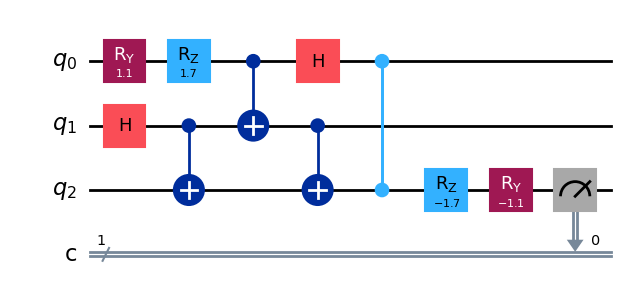

In [11]:
qc.draw('mpl')

In [18]:
backend = Aer.get_backend('qasm_simulator')
job = backend.run(qc, shots=5000)
result = job.result()
counts = result.get_counts()

In [19]:
counts

{'0': 5000}

Teleportation -> PART B


1. What do you observe in the histogram after applying U†?

Answer: After applying U†, Bob measures |0⟩ with ~100% probability.

2. Why does applying U† verify teleportation?

Answer: U†U=|0⟩, Bob receives |ψ⟩, and applying U† returns it to |0⟩, confirming the state was correctly teleported.

3. Why were we able to avoid sending classical bits in this assignment?

Answer: We used coherent controlled gates (CX and CZ) instead of measurement + classical communication.
The correction keeps the circuit fully unitary.

PART 2: SUPERDENSE CODING -> PART A

In [21]:
qc2 = QuantumCircuit(2, 2)

In [22]:
qc2.h(0)
qc2.cx(0, 1)

In [23]:
qc2.x(0)

In [24]:
qc2.cx(0, 1)
qc2.h(0)

In [25]:
qc2.measure([0, 1], [0, 1])

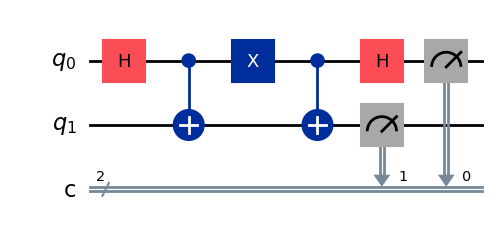

In [26]:
qc2.draw('mpl')

In [28]:
job2 = backend.run(qc2, shots=5000)
result2 = job2.result()
counts2 = result2.get_counts()

In [29]:
counts2

{'10': 5000}

PART 2: SUPERDENSE CODING -> PART B

1. Explain what happens if an eavesdropper intercepts the qubit sent from Alice to Bob?

Answer: They only get one qubit, which by itself is in a maximally mixed state. Without the entangled partner, they cannot extract the 2-bit message.

2. Give one application or implication of superdense coding.

Answer: Used in quantum networks to send more information per qubit